# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [61]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [63]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}


# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [64]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_cv_results = pd.DataFrame(svm_grid_search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')
print(svm_cv_results.head(10).to_string(index=False))

                                                         params  mean_test_score  std_test_score  rank_test_score
       {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
  {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
     {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
      {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
     {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
    {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969350        

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [66]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_baseline = base_models['SVM']
svm_baseline.fit(X_train, y_train)
y_pred_svm_base = svm_baseline.predict(X_test)
svm_base_report = classification_report(y_test, y_pred_svm_base, output_dict=True)

svm_grid_best = svm_grid_search.best_estimator_
y_pred_svm_grid = svm_grid_best.predict(X_test)
svm_grid_report = classification_report(y_test, y_pred_svm_grid, output_dict=True)

rf_baseline = base_models['RandomForest']
rf_baseline.fit(X_train, y_train)
y_pred_rf_base = rf_baseline.predict(X_test)
rf_base_report = classification_report(y_test, y_pred_rf_base, output_dict=True)

rf_best = rf_random_search.best_estimator_
y_pred_rf_rand = rf_best.predict(X_test)
rf_rand_report = classification_report(y_test, y_pred_rf_rand, output_dict=True)

print("\nSVM baseline:\n", classification_report(y_test, y_pred_svm_base))
print("\nSVM Grid Search:\n", classification_report(y_test, y_pred_svm_grid))
print("\nRF baseline:\n", classification_report(y_test, y_pred_rf_base))
print("\nRF Random Search:\n", classification_report(y_test, y_pred_rf_rand))


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

svm_base_f1_test = svm_base_report['weighted avg']['f1-score']
svm_grid_f1_test = svm_grid_report['weighted avg']['f1-score']
rf_base_f1_test = rf_base_report['weighted avg']['f1-score']
rf_rand_f1_test = rf_rand_report['weighted avg']['f1-score']

comparison_table = pd.DataFrame({
    'Модель': ['SVM baseline', 'SVM Grid Search', 'RF baseline', 'RF Random Search'],
    'CV F1 (mean±std)': [
        f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        f"{svm_grid_search.best_score_:.4f} ± {svm_cv_results.iloc[0]['std_test_score']:.4f}",
        f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        f"{rf_random_search.best_score_:.4f} ± {pd.Series(rf_random_search.cv_results_['std_test_score']).min():.4f}"
    ],
    'Test F1': [svm_base_f1_test, svm_grid_f1_test, rf_base_f1_test, rf_rand_f1_test]
})
print(comparison_table.to_string(index=False))


SVM baseline:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


SVM Grid Search:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


RF baseline:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96 

## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

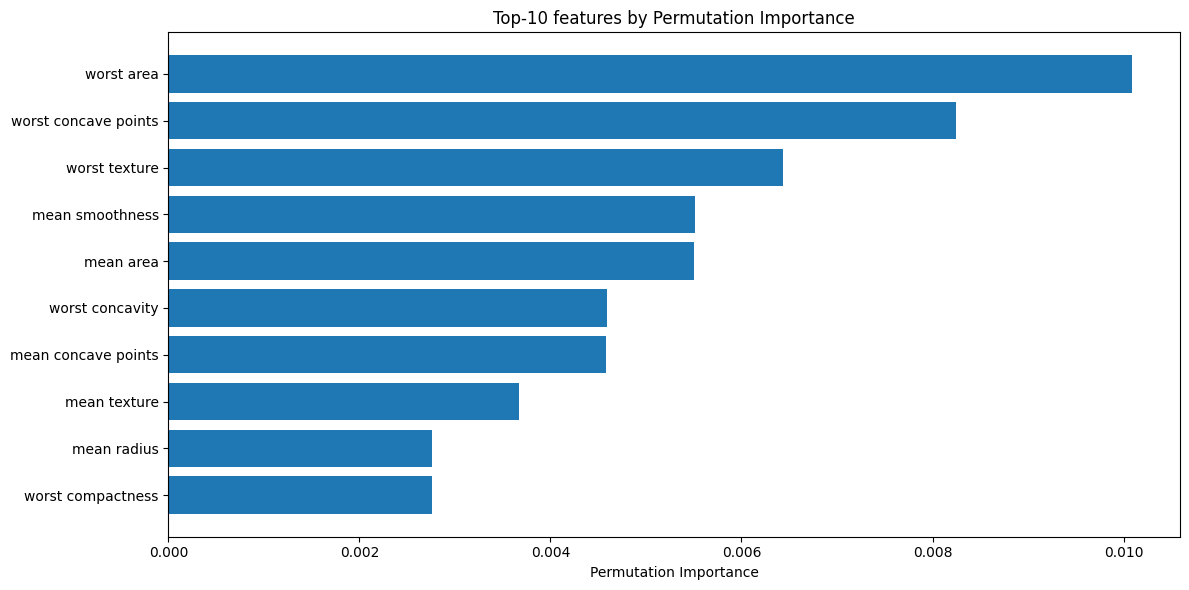

In [67]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro'
)


# Построим bar plot топ-10 признаков
# YOUR CODE HERE
top10_idx = np.argsort(pi_result.importances_mean)[::-1][:10]
plt.figure(figsize=(12, 6))
plt.barh(feature_names[top10_idx][::-1], pi_result.importances_mean[top10_idx][::-1])
plt.xlabel('Permutation Importance')
plt.title('Top-10 features by Permutation Importance')
plt.tight_layout()
plt.show()

In [68]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
intrinsic_idx = np.argsort(best_rf.feature_importances_)[::-1][:5]
pi_top5 = feature_names[np.argsort(pi_result.importances_mean)[::-1][:5]].astype(str).tolist()
intrinsic_top5 = feature_names[intrinsic_idx].astype(str).tolist()

print("PI top-5:", list(pi_top5))
print("Intrinsic top-5:", list(intrinsic_top5))
print("Совпадение топ-5:", list(pi_top5) == list(intrinsic_top5))

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

PI top-5: ['worst area', 'worst concave points', 'worst texture', 'mean smoothness', 'mean area']
Intrinsic top-5: ['worst area', 'worst perimeter', 'worst concave points', 'worst radius', 'mean concave points']
Совпадение топ-5: False


топ-5 не совпадают. если признаки коррелированы, то при перемешивании одного из них модель  будет использовать другой, поэтому PI может занизить важность первого признака

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

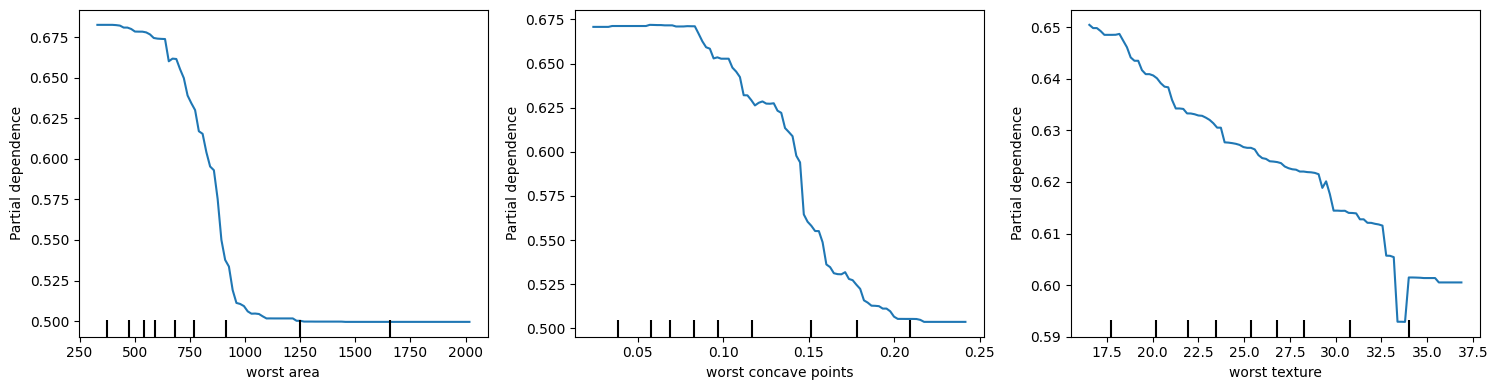

In [69]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[::-1][:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
for i, idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_train, features=[idx], kind='average', ax=ax[i]
    )
plt.tight_layout()
plt.show()

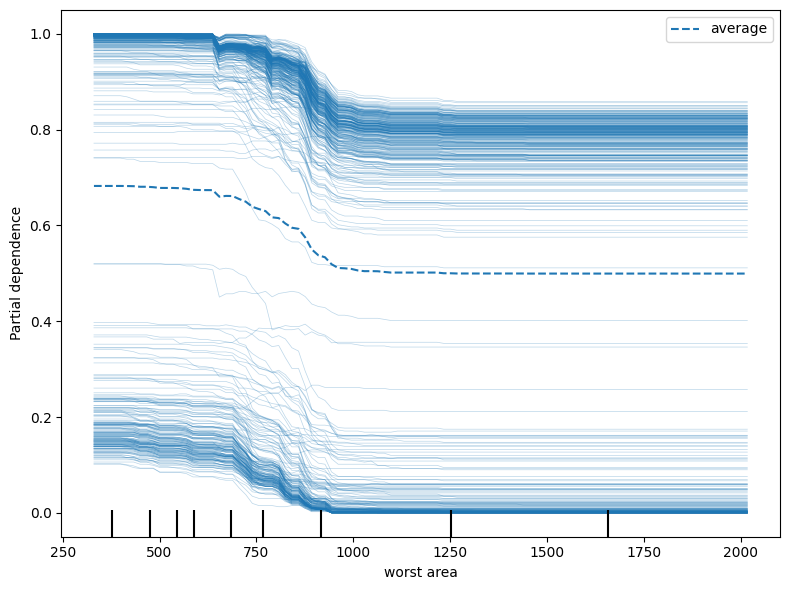

In [70]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features=[top3_idx[0]], kind='both', ax=ax
)
plt.tight_layout()
plt.show()


эффект неоднороден

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [71]:
# Установка SHAP (если не установлен)
#!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(np.array(shap_values).shape)

(114, 30, 2)


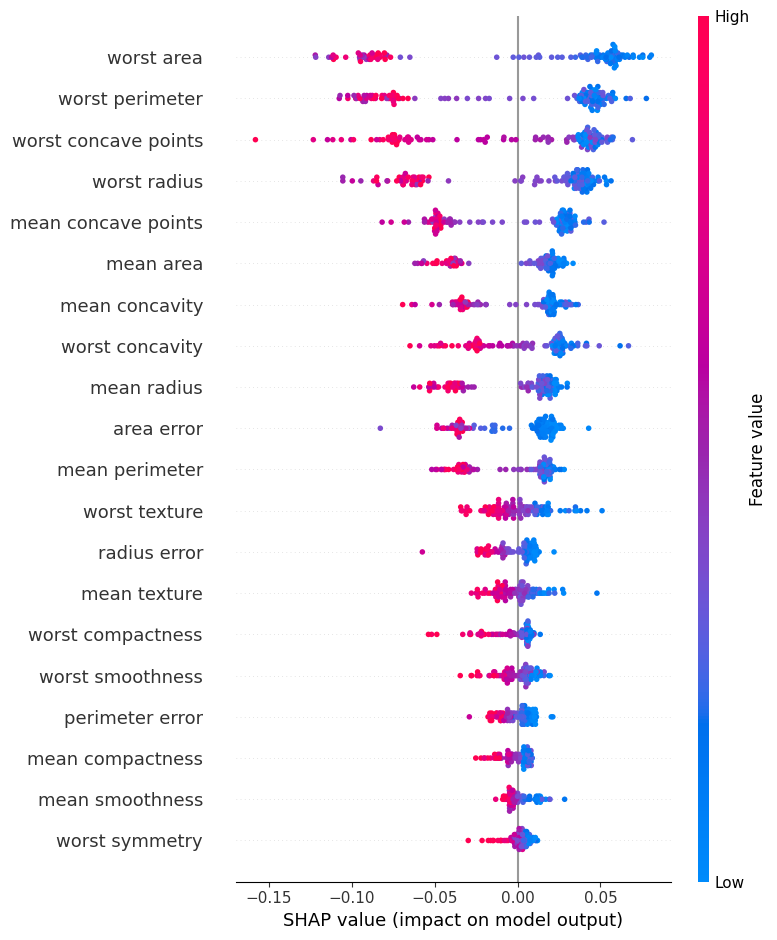

In [72]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_values_for_plot = shap_values[:, :, 1]
shap.summary_plot(shap_values_for_plot, X_test, feature_names=feature_names)

топ-5 shap и pi не совпадают

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


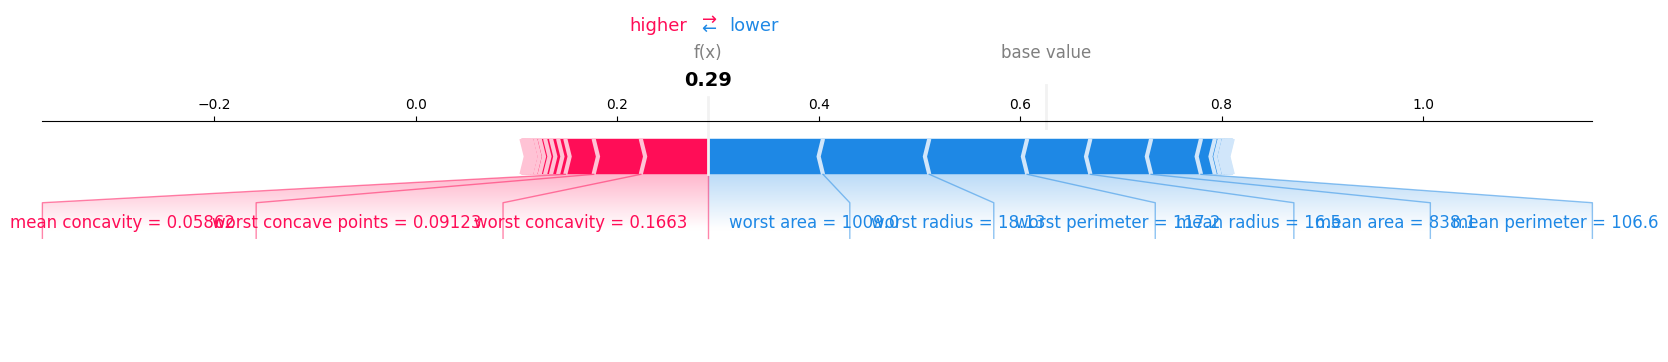

Виноваты признаки:
worst area -0.11400752725114423 1009.0
worst radius -0.10551425967958857 18.13
worst perimeter -0.09724467811321894 117.2
worst concavity 0.06691644929550239 0.1663
mean radius -0.06271698995562001 16.5


In [73]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
shap.force_plot(
    explainer.expected_value[1],
    shap_values_for_plot[errors[0]],
    X_test.iloc[errors[0]],
    matplotlib=True
)

print("Виноваты признаки:")
i = errors[0]
vals = shap_values_for_plot[i]
top_idx = np.argsort(np.abs(vals))[::-1][:5]
for j in top_idx:
    print(feature_names[j], vals[j], X_test.iloc[i, j])

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [74]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

leaky_feature PI: 0.2633
random_feature PI: 0.0000


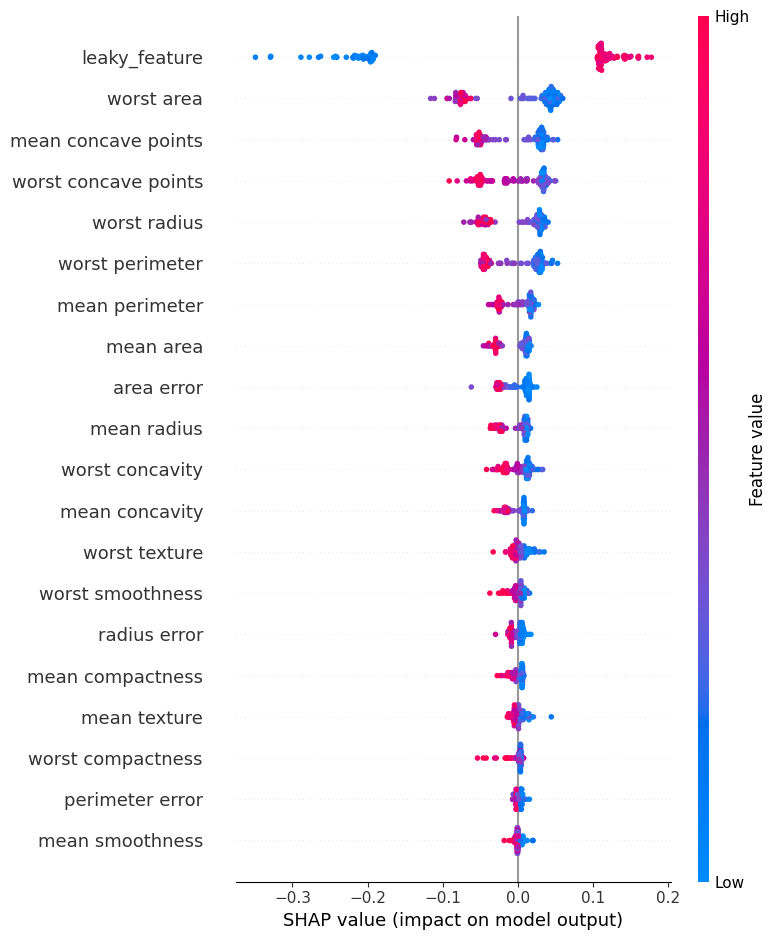

In [75]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro'
)

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
shap_values_ext_plot = shap_values_ext[:, :, 1]


ext_feature_names = X_train_ext.columns
leaky_idx = list(ext_feature_names).index('leaky_feature')
random_idx = list(ext_feature_names).index('random_feature')

print(f"leaky_feature PI: {pi_ext.importances_mean[leaky_idx]:.4f}")
print(f"random_feature PI: {pi_ext.importances_mean[random_idx]:.4f}")

shap.summary_plot(shap_values_ext_plot, X_test_ext, feature_names=ext_feature_names)

a) leaky_feature получает высокий PI, потому что она почти напрямую содержит таргет

тестовая метрика выросла, потому что утечка

б) leaky_feature в SHAP на первом месте 

в) random_feature шумовой, т.к. PI=0 и в SHAP его вообще нет

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [76]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
summary_table = pd.DataFrame({
    'Метод': ['SVM baseline', 'SVM Grid Search', 'RF baseline', 'RF Rand Search'],
    'CV F1': [
        baseline_results['SVM'][0],
        svm_grid_search.best_score_,
        baseline_results['RandomForest'][0],
        rf_random_search.best_score_
    ],
    'Test F1': [svm_base_f1_test, svm_grid_f1_test, rf_base_f1_test, rf_rand_f1_test],
    'Выводы': [
        'Хороший старт',
        'Grid Search улучшил SVM',
        'Базовый RF',
        'Random Search улучшил RF'
    ]
})
print(summary_table.to_string(index=False))

          Метод    CV F1  Test F1                   Выводы
   SVM baseline 0.969357 0.982456            Хороший старт
SVM Grid Search 0.978633 0.982456  Grid Search улучшил SVM
    RF baseline 0.950427 0.956027               Базовый RF
 RF Rand Search 0.955384 0.956027 Random Search улучшил RF


1.

SVM: +0.0093 по CV F1
RF: +0.0050 по CV F1

2.

нет. PI измеряет падение метрики при перемешивании признака, а SHAP смотрит вклад каждого признака в отклонение предсказания от среднего.

3.

Риск data leakage и оптимистичной оценки в CV.

4.
PI — для быстрой глобальной оценки важности признаков,
SHAP — для локальных объяснений, проверки аномалий, лучше справляется с корреляциями 

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

#import optuna
#optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")

ModuleNotFoundError: No module named 'optuna'